In [ ]:
#Group 2:canteen_sales_analysis of case study .
#group members:
#  1. Shwetyadav(590028737) 
# 2.Gajendra kumar(590020561) 
# 3.Nandini tiwari(590021535) 
# 4. Abhinav rawat(590023337) 
# 5. Deepti kumari(590020405) 
# 6.Harshit dwivedi(590025793) 7
# . Shourya kumar(590025952)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import pandas as pd

# Load dataset
df = pd.read_excel(r"C:\Users\shwet\Downloads\canteen_sales_data.xlsx")

# Convert datetime
df['Date & Time'] = pd.to_datetime(df['Date & Time'])

# Create useful columns
df['Hour'] = df['Date & Time'].dt.hour
df['Day'] = df['Date & Time'].dt.day_name()

In [ ]:
#1. Basic Insight
total_orders = df['Order ID'].nunique()
print(total_orders)

250


In [5]:
status_percent = df['Order Status'].value_counts(normalize=True) * 100
print(status_percent)

Order Status
Completed    91.2
Cancelled     8.8
Name: proportion, dtype: float64


In [6]:
most_sold = df.groupby('Item Name')['Quantity'].sum().sort_values(ascending=False)
print(most_sold.head(1))

Item Name
Veg Sandwich    53
Name: Quantity, dtype: int64


In [7]:
#2. Time-based analysis
orders_by_hour = df.groupby('Hour')['Order ID'].count().sort_values(ascending=False)
print(orders_by_hour)

Hour
19    23
20    23
13    22
16    21
12    21
9     20
14    19
11    19
15    18
17    18
18    17
10    15
8     14
Name: Order ID, dtype: int64


In [8]:
sales_by_day = df.groupby('Day')['Total Amount'].sum().sort_values(ascending=False)
print(sales_by_day)

Day
Tuesday      7545
Saturday     7470
Thursday     6975
Sunday       6635
Friday       6605
Monday       5810
Wednesday    5330
Name: Total Amount, dtype: int64


In [9]:
peak_hours = orders_by_hour.head(3)
print(peak_hours)

Hour
19    23
20    23
13    22
Name: Order ID, dtype: int64


In [10]:
def time_slot(hour):
    if hour < 12:
        return 'Morning'
    elif hour < 17:
        return 'Afternoon'
    else:
        return 'Evening'

df['Time Slot'] = df['Hour'].apply(time_slot)

sales_by_slot = df.groupby('Time Slot')['Total Amount'].sum()
print(sales_by_slot)

Time Slot
Afternoon    18715
Evening      13775
Morning      13880
Name: Total Amount, dtype: int64


In [11]:
peak_hour_list = peak_hours.index.tolist()

cancel_peak = df[(df['Hour'].isin(peak_hour_list)) & 
                 (df['Order Status'] == 'Cancelled')]

cancel_non_peak = df[(~df['Hour'].isin(peak_hour_list)) & 
                     (df['Order Status'] == 'Cancelled')]

print("Peak cancellations:", len(cancel_peak))
print("Non-peak cancellations:", len(cancel_non_peak))

Peak cancellations: 6
Non-peak cancellations: 16


In [12]:
#Section 3: Menu & Product Insights
# Group items per order
order_items = df.groupby('Order ID')['Item Name'].apply(list)

# Count pairs
from itertools import combinations
from collections import Counter

pair_counts = Counter()

for items in order_items:
    pairs = combinations(sorted(set(items)), 2)
    pair_counts.update(pairs)

print(pair_counts.most_common(5))

[]


In [13]:
avg_qty = df.groupby('Item Name')['Quantity'].mean().sort_values(ascending=False)
print(avg_qty.head(1))

Item Name
Chicken Sandwich    2.857143
Name: Quantity, dtype: float64


In [14]:
#Section 4: Payment Behavior
payment_percent = df['Payment Mode'].value_counts(normalize=True) * 100
print(payment_percent)

Payment Mode
Online    58.0
Cash      42.0
Name: proportion, dtype: float64


In [15]:
aov = df.groupby('Payment Mode')['Total Amount'].mean()
print(aov)

Payment Mode
Cash      183.571429
Online    186.862069
Name: Total Amount, dtype: float64


In [16]:
cancel_by_payment = df[df['Order Status'] == 'Cancelled']['Payment Mode'].value_counts()
print(cancel_by_payment)

Payment Mode
Online    16
Cash       6
Name: count, dtype: int64


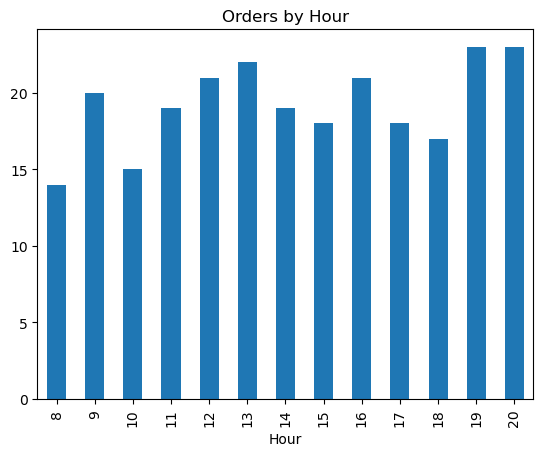

In [17]:
import matplotlib.pyplot as plt

# Orders by hour
orders_by_hour.sort_index().plot(kind='bar')
plt.title("Orders by Hour")
plt.show()

In [18]:
#SECTION 5: OPERATIONAL INSIGHTS
peak_hours = df['Hour'].value_counts().head(3).index.tolist()
peak_data = df[df['Hour'].isin(peak_hours)]
peak_items = peak_data.groupby('Item Name')['Quantity'].sum().sort_values(ascending=False)
print(peak_items)

Item Name
Juice               21
Tea                 19
Coffee              17
Pizza Slice         17
Veg Sandwich        16
Momos               13
Burger              12
Cold Drink          11
Wrap                10
Salad                9
Fries                7
Noodles              5
Pasta                5
Chicken Sandwich     3
Samosa               1
Name: Quantity, dtype: int64


In [19]:
# High quantity orders threshold (example: >2 items per order)
high_qty = df[df['Quantity'] > 2]
delay_items = high_qty.groupby('Item Name')['Quantity'].sum().sort_values(ascending=False)
print(delay_items)

Item Name
Wrap                40
Salad               36
Burger              36
Veg Sandwich        36
Tea                 33
Chicken Sandwich    33
Momos               33
Cold Drink          32
Noodles             25
Juice               25
Coffee              23
Fries               22
Pasta               20
Samosa              19
Pizza Slice         17
Name: Quantity, dtype: int64


In [20]:
avg_order_value = df.groupby('Order ID')['Total Amount'].sum().mean()
print("Average Order Value:", avg_order_value)

Average Order Value: 185.48


In [22]:
#SECTION 6: DASHBOARD TASKS (PYTHON VISUALS)
total_orders = df['Order ID'].nunique()
cancel_percent = (df[df['Order Status'] == 'Cancelled'].shape[0] / len(df)) * 100
print("Total Orders:", total_orders)
print("Cancellation %:", cancel_percent)

Total Orders: 250
Cancellation %: 8.799999999999999


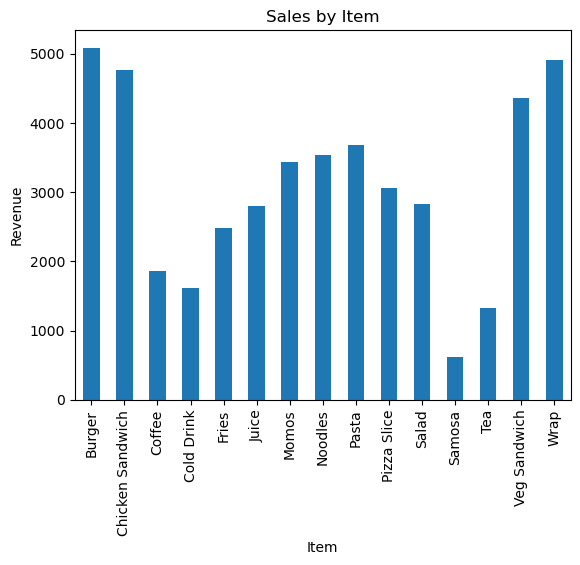

In [23]:
import matplotlib.pyplot as plt
sales_item = df.groupby('Item Name')['Total Amount'].sum()
sales_item.plot(kind='bar')
plt.title("Sales by Item")
plt.xlabel("Item")
plt.ylabel("Revenue")
plt.show()

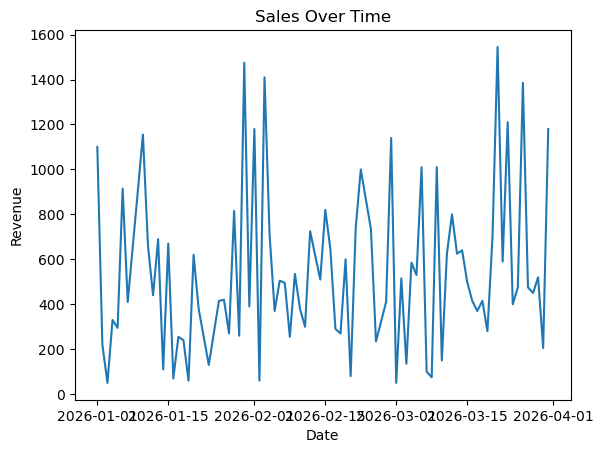

In [24]:
# Daily sales
df['Date'] = df['Date & Time'].dt.date
sales_time = df.groupby('Date')['Total Amount'].sum()
sales_time.plot(kind='line')
plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

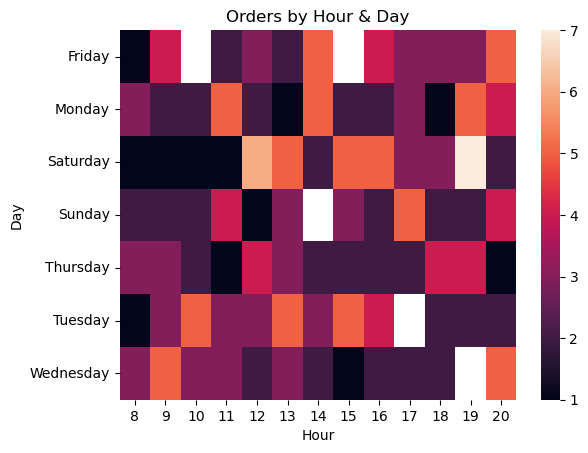

In [25]:
import seaborn as sns
heatmap_data = df.pivot_table(
    values='Order ID',
    index='Day',
    columns='Hour',
    aggfunc='count'
)
sns.heatmap(heatmap_data)
plt.title("Orders by Hour & Day")
plt.show()

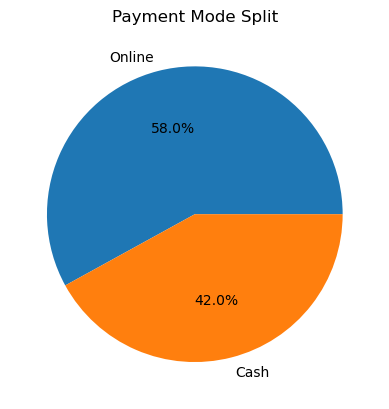

In [26]:
payment = df['Payment Mode'].value_counts()
payment.plot(kind='pie', autopct='%1.1f%%')
plt.title("Payment Mode Split")
plt.ylabel("")
plt.show()

In [27]:
peak_lunch = df[(df['Hour'] >= 13) & (df['Hour'] <= 14)]
lunch_orders = peak_lunch['Order ID'].count()
print("Orders between 1–2 PM:", lunch_orders)

Orders between 1–2 PM: 41


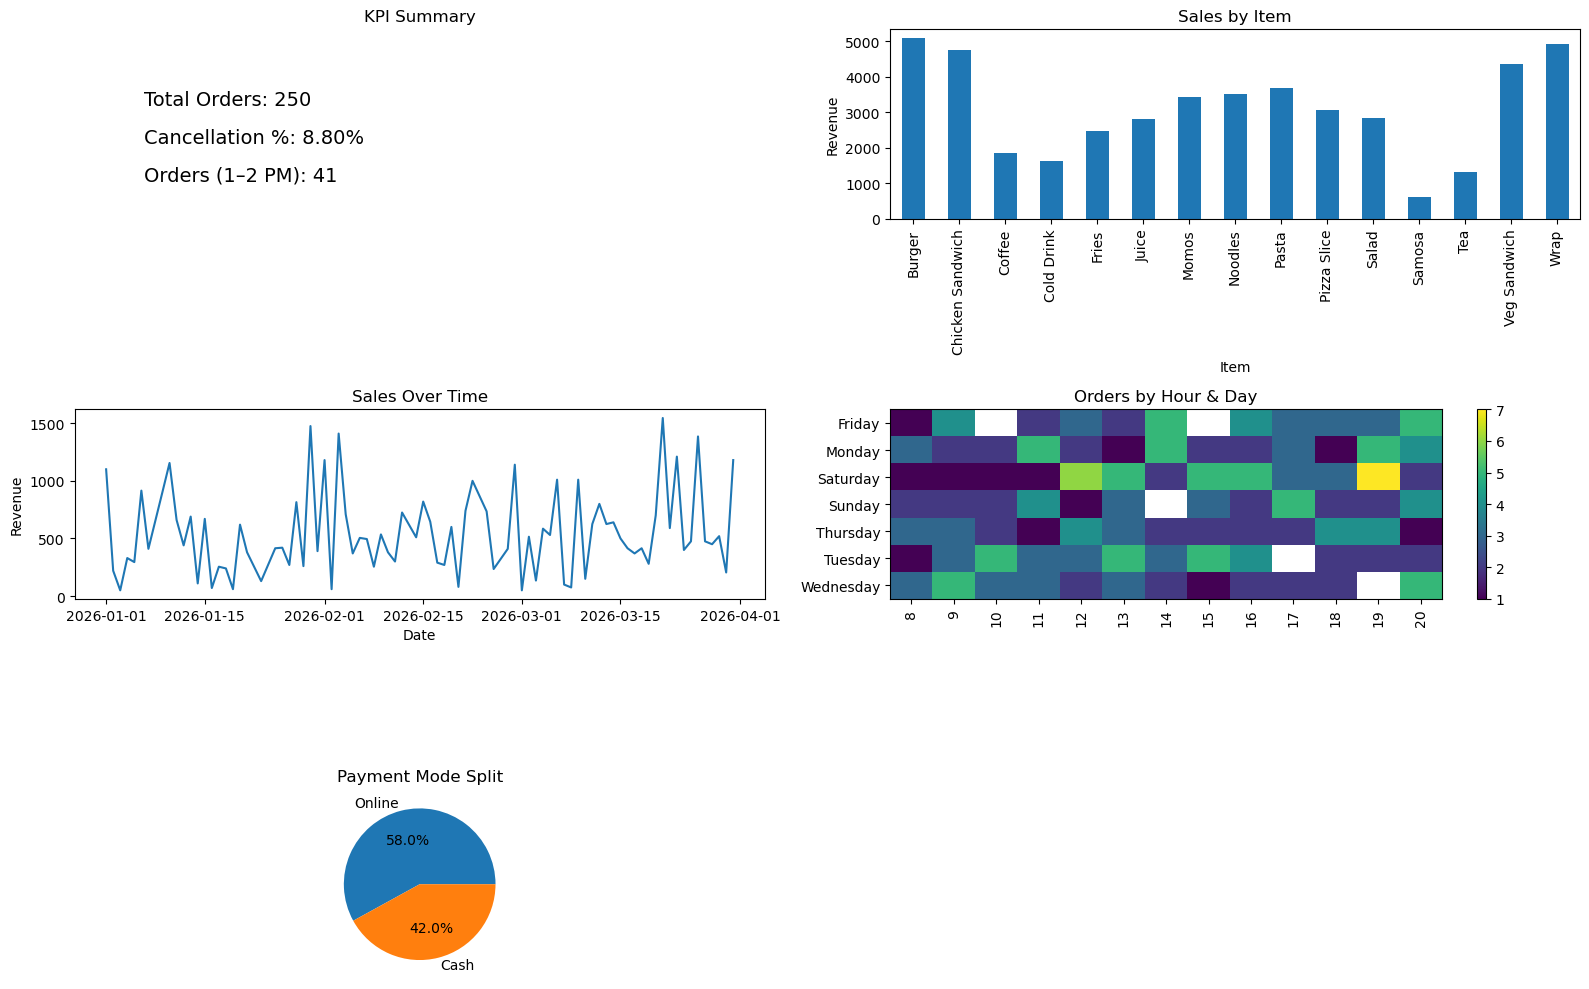

In [28]:
# Data preprocessing
df['Date & Time'] = pd.to_datetime(df['Date & Time'])
df['Hour'] = df['Date & Time'].dt.hour
df['Day'] = df['Date & Time'].dt.day_name()
df['Date'] = df['Date & Time'].dt.date

# ---------------- KPI CALCULATIONS ----------------
total_orders = df['Order ID'].nunique()
cancel_percent = (df[df['Order Status'] == 'Cancelled'].shape[0] / len(df)) * 100

# ---------------- DATA PREPARATION ----------------
# Sales by item
sales_item = df.groupby('Item Name')['Total Amount'].sum()

# Sales over time
sales_time = df.groupby('Date')['Total Amount'].sum()

# Orders by hour & day (heatmap data)
heatmap_data = df.pivot_table(
    values='Order ID',
    index='Day',
    columns='Hour',
    aggfunc='count'
)

# Payment mode split
payment = df['Payment Mode'].value_counts()

# Peak orders (1–2 PM)
peak_lunch = df[(df['Hour'] >= 13) & (df['Hour'] <= 14)]
lunch_orders = peak_lunch['Order ID'].count()

# ---------------- DASHBOARD ----------------
plt.figure(figsize=(16, 10))

# KPI TEXT (Top)
plt.subplot(3, 2, 1)
plt.text(0.1, 0.6, f"Total Orders: {total_orders}", fontsize=14)
plt.text(0.1, 0.4, f"Cancellation %: {cancel_percent:.2f}%", fontsize=14)
plt.text(0.1, 0.2, f"Orders (1–2 PM): {lunch_orders}", fontsize=14)
plt.axis('off')
plt.title("KPI Summary")

# Bar Chart: Sales by Item
plt.subplot(3, 2, 2)
sales_item.plot(kind='bar')
plt.title("Sales by Item")
plt.xlabel("Item")
plt.ylabel("Revenue")

# Line Chart: Sales Over Time
plt.subplot(3, 2, 3)
sales_time.plot(kind='line')
plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue")

# Heatmap (Manual using imshow instead of seaborn)
plt.subplot(3, 2, 4)
plt.imshow(heatmap_data, aspect='auto')
plt.colorbar()
plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns, rotation=90)
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)
plt.title("Orders by Hour & Day")

# Pie Chart: Payment Mode
plt.subplot(3, 2, 5)
payment.plot(kind='pie', autopct='%1.1f%%')
plt.title("Payment Mode Split")
plt.ylabel("")

# Adjust layout
plt.tight_layout()
plt.show()